<a href="https://colab.research.google.com/github/70hnP/localNashRepository/blob/main/Bomba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Librerías para manejo de datos
import numpy as np
import pandas as pd

In [2]:
# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Librerías para machine learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [6]:
# Configuración de visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [7]:
# CARGA Y PREPROCESAMIENTO DE DATOS
df = pd.read_csv('datos_bomba_centifuga.csv', sep=';')
print(f"Datos cargados: {df.shape[0]} registros, {df.shape[1]} columnas")

Datos cargados: 500 registros, 11 columnas


In [8]:
# Normalizar nombres de columnas
df.columns = df.columns.str.lower().str.replace(' ', '_')
string_columns = list(df.dtypes[df.dtypes == 'object'].index)
for col in string_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')

df.head()

,timestamp,caudal_(m3/h),altura_(m),eficiencia_(%),potencia_eje_(kw),vibracion_(mm/s),temp._cojinete_(°c),presion_sucion_(bar),presion_descarga_(bar),rpm,estado
0,2023-01-01_00:00:00,41.712047,41.805006,69.558673,6.990899,3.089441,25.468689,1.918378,6.015269,1439.019361,normal
1,2023-01-01_00:05:00,107.392830,-0.179646,67.035327,0.468453,5.306597,24.122612,2.007814,1.990209,1449.189380,warning
2,2023-01-01_00:10:00,81.944969,17.878512,82.310407,4.653314,4.363581,26.355530,2.086164,3.838258,1450.715244,normal
3,2023-01-01_00:15:00,64.987078,28.871637,85.467571,5.773244,3.946722,26.612574,2.013906,4.843326,1454.248060,normal
4,2023-01-01_00:20:00,15.814428,48.937561,36.852482,6.343786,2.583690,23.788191,1.842300,6.638181,1453.464288,alarm


In [9]:
# Exploración de Datos
print("Primeras 5 filas del dataset:")
display(df.head())

print(f"\nInformación del dataset:")
print(f" - Total de registros: {len(df)}")
print(f" - Total de columnas: {len(df.columns)}")

print(f"\nColumnas disponibles:")
for col in df.columns:
    print(f" - {col}")

print("\nEstadísticas Descriptivas:")
df.describe().round(2)

print("\nVerificación de Valores Nulos:")
null_counts = df.isnull().sum()

if null_counts.sum() == 0:
    print(" No hay valores nulos en el dataset")
else:
    print(" Se encontraron valores nulos:")
    print(null_counts[null_counts > 0])

Primeras 5 filas del dataset:


,timestamp,caudal_(m3/h),altura_(m),eficiencia_(%),potencia_eje_(kw),vibracion_(mm/s),temp._cojinete_(°c),presion_sucion_(bar),presion_descarga_(bar),rpm,estado
0,2023-01-01_00:00:00,41.712047,41.805006,69.558673,6.990899,3.089441,25.468689,1.918378,6.015269,1439.019361,normal
1,2023-01-01_00:05:00,107.392830,-0.179646,67.035327,0.468453,5.306597,24.122612,2.007814,1.990209,1449.189380,warning
2,2023-01-01_00:10:00,81.944969,17.878512,82.310407,4.653314,4.363581,26.355530,2.086164,3.838258,1450.715244,normal
3,2023-01-01_00:15:00,64.987078,28.871637,85.467571,5.773244,3.946722,26.612574,2.013906,4.843326,1454.248060,normal
4,2023-01-01_00:20:00,15.814428,48.937561,36.852482,6.343786,2.583690,23.788191,1.842300,6.638181,1453.464288,alarm



Información del dataset:
 - Total de registros: 500
 - Total de columnas: 11

Columnas disponibles:
 - timestamp
 - caudal_(m3/h)
 - altura_(m)
 - eficiencia_(%)
 - potencia_eje_(kw)
 - vibracion_(mm/s)
 - temp._cojinete_(°c)
 - presion_sucion_(bar)
 - presion_descarga_(bar)
 - rpm
 - estado

Estadísticas Descriptivas:

Verificación de Valores Nulos:
 No hay valores nulos en el dataset


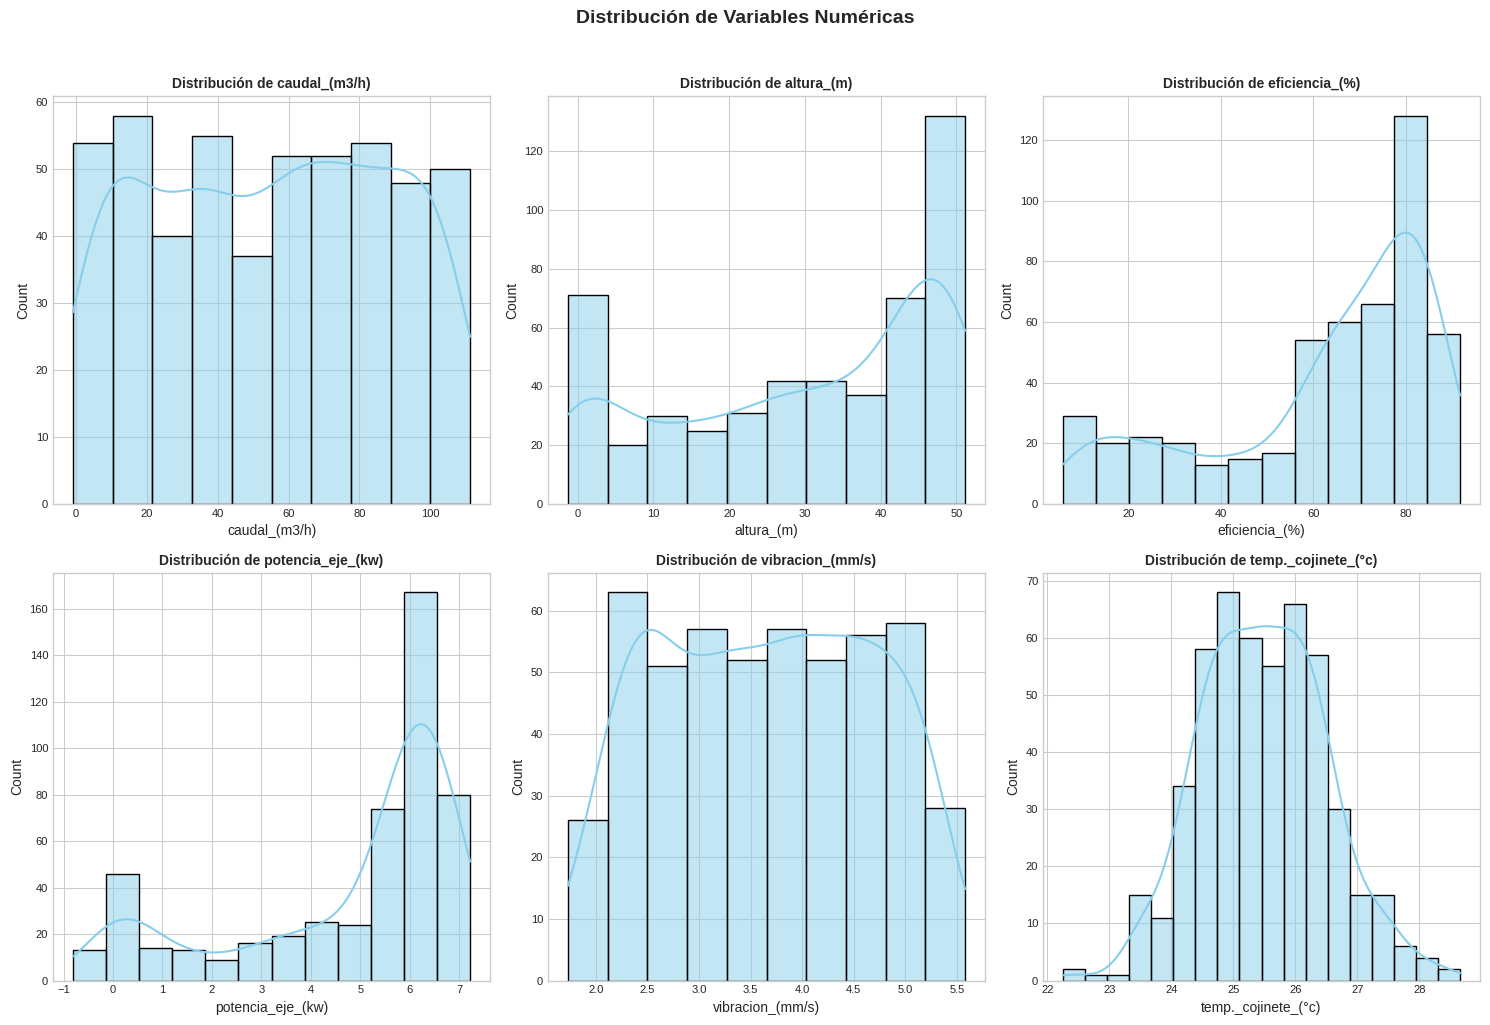

In [10]:
# Distribución de Variables
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

variables = df.select_dtypes(include=[np.number]).columns.tolist()

for i, var in enumerate(variables):
    if i < len(axes):
        sns.histplot(data=df, x=var, kde=True, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Distribución de {var}', fontsize=10, fontweight='bold')
        axes[i].tick_params(labelsize=8)

plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribucion_variables.png', dpi=300, bbox_inches='tight')
plt.show()

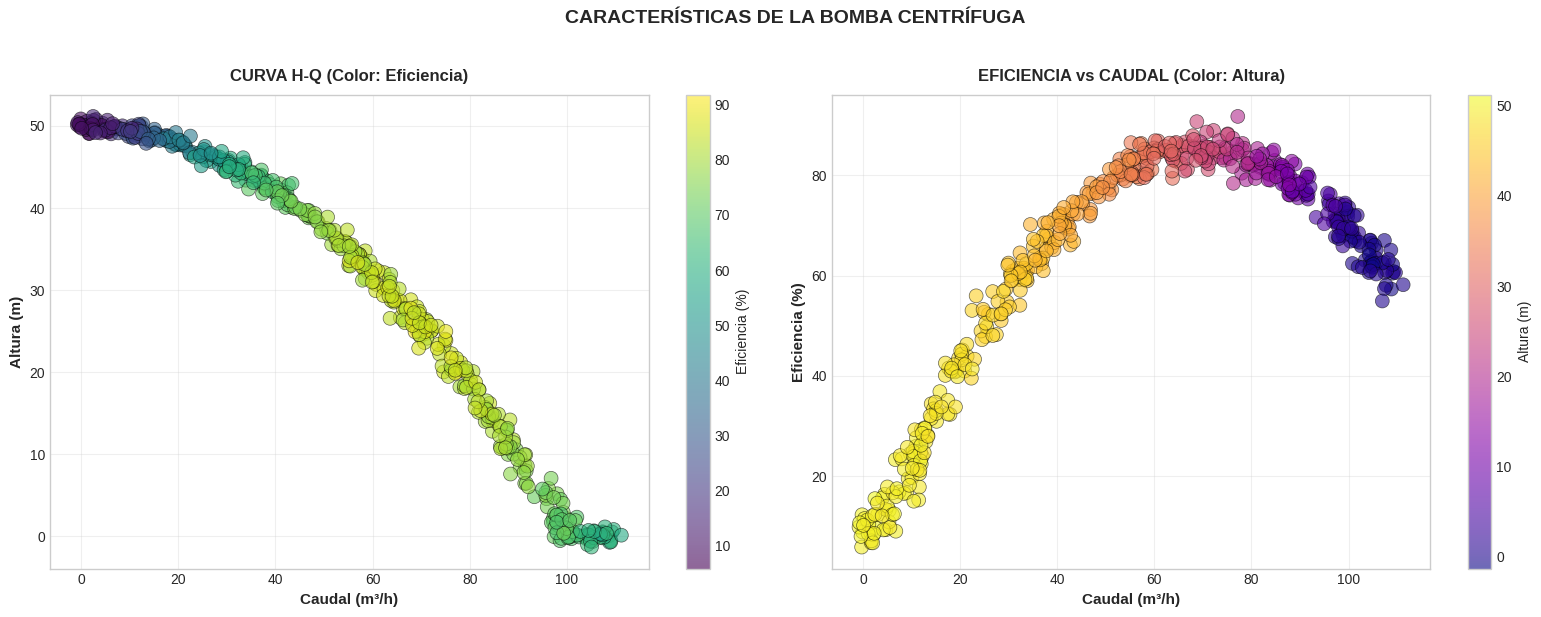

In [11]:
# Curva H-Q
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(
    df['caudal_(m3/h)'],
    df['altura_(m)'],
    c=df['eficiencia_(%)'],
    cmap='viridis',
    alpha=0.6,
    s=100,
    edgecolors='black',
    linewidth=0.5
)
axes[0].set_xlabel('Caudal (m³/h)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Altura (m)', fontsize=11, fontweight='bold')
axes[0].set_title('CURVA H-Q (Color: Eficiencia)', fontsize=12, fontweight='bold', pad=10)
plt.colorbar(scatter1, ax=axes[0], label='Eficiencia (%)')
axes[0].grid(True, alpha=0.3)

scatter2 = axes[1].scatter(
    df['caudal_(m3/h)'],
    df['eficiencia_(%)'],
    c=df['altura_(m)'],
    cmap='plasma',
    alpha=0.6,
    s=100,
    edgecolors='black',
    linewidth=0.5
)
axes[1].set_xlabel('Caudal (m³/h)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Eficiencia (%)', fontsize=11, fontweight='bold')
axes[1].set_title('EFICIENCIA vs CAUDAL (Color: Altura)', fontsize=12, fontweight='bold', pad=10)
plt.colorbar(scatter2, ax=axes[1], label='Altura (m)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('CARACTERÍSTICAS DE LA BOMBA CENTRÍFUGA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('curva_hq_eficiencia.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# Cálculo del BEP (Best Efficiency Point)
def calcular_bep(df):
    """Calcula el Punto de Mejor Eficiencia (BEP)"""
    bep_idx = df['eficiencia_(%)'].idxmax()

    bep = {
        'indice': bep_idx,
        'caudal': df.loc[bep_idx, 'caudal_(m3/h)'],
        'altura': df.loc[bep_idx, 'altura_(m)'],
        'eficiencia': df.loc[bep_idx, 'eficiencia_(%)'],
        'potencia': df.loc[bep_idx, 'potencia_eje_(kw)'],
        'vibracion': df.loc[bep_idx, 'vibracion_(mm/s)'],
        'temperatura': df.loc[bep_idx, 'temp._cojinete_(°c)'],
        'rpm': df.loc[bep_idx, 'rpm']
    }

    return bep

bep = calcular_bep(df)

print("=" * 60)
print("PUNTO DE MEJOR EFICIENCIA (BEP)".center(60))
print("=" * 60)
print(f"\n{'Parámetro':<25} {'Valor':>15} {'Unidad':>10}")
print("-" * 60)
print(f"{'Caudal':<25} {bep['caudal']:>15.2f} {'m³/h':>10}")
print(f"{'Altura':<25} {bep['altura']:>15.2f} {'m':>10}")
print(f"{'Eficiencia':<25} {bep['eficiencia']:>15.2f} {'%':>10}")
print(f"{'Potencia del Eje':<25} {bep['potencia']:>15.2f} {'kW':>10}")
print(f"{'Vibración':<25} {bep['vibracion']:>15.2f} {'mm/s':>10}")
print(f"{'Temp. Cojinete':<25} {bep['temperatura']:>15.2f} {'°C':>10}")
print(f"{'RPM':<25} {bep['rpm']:>15.0f} {'rpm':>10}")
print("=" * 60)

              PUNTO DE MEJOR EFICIENCIA (BEP)               

Parámetro                           Valor     Unidad
------------------------------------------------------------
Caudal                              77.18       m³/h
Altura                              19.99          m
Eficiencia                          91.77          %
Potencia del Eje                     5.03         kW
Vibración                            4.24       mm/s
Temp. Cojinete                      24.05         °C
RPM                                  1455        rpm


In [13]:
# Preparación de Datos
features = [
    'caudal_(m3/h)',
    'altura_(m)',
    'potencia_eje_(kw)',
    'vibracion_(mm/s)',
    'temp._cojinete_(°c)',
    'rpm'
]
target = 'eficiencia_(%)'

print("PREPARACIÓN DE DATOS")
print("=" * 60)

print(f"\nVariables Predictoras (X):")
for i, feature in enumerate(features, 1):
    print(f" {i}. {feature}")

print(f"\nVariable Objetivo (y):")
print(f" - {target}")

# Verificar y eliminar valores nulos antes de convertir a numpy
if df[features + [target]].isnull().sum().sum() > 0:
    print("Advertencia: Hay valores nulos. Eliminando filas...")
    df = df.dropna(subset=features + [target])

X = df[features].values
y = df[target].values

print(f"\nDimensiones:")
print(f" X: {X.shape} (registros × características)")
print(f" y: {y.shape} (registros,)")

PREPARACIÓN DE DATOS

Variables Predictoras (X):
 1. caudal_(m3/h)
 2. altura_(m)
 3. potencia_eje_(kw)
 4. vibracion_(mm/s)
 5. temp._cojinete_(°c)
 6. rpm

Variable Objetivo (y):
 - eficiencia_(%)

Dimensiones:
 X: (500, 6) (registros × características)
 y: (500,) (registros,)


In [14]:
# División Train-Test
RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("DIVISIÓN DE DATOS")
print("=" * 60)

print(f"\nConjunto de Entrenamiento:")
print(f" - Registros: {len(X_train)} ({(1-TEST_SIZE)*100:.0f}%)")
print(f" - X_train: {X_train.shape}")
print(f" - y_train: {y_train.shape}")

print(f"\nConjunto de Prueba:")
print(f" - Registros: {len(X_test)} ({TEST_SIZE*100:.0f}%)")
print(f" - X_test: {X_test.shape}")
print(f" - y_test: {y_test.shape}")

print(f"\nSemilla aleatoria: {RANDOM_STATE}")

DIVISIÓN DE DATOS

Conjunto de Entrenamiento:
 - Registros: 400 (80%)
 - X_train: (400, 6)
 - y_train: (400,)

Conjunto de Prueba:
 - Registros: 100 (20%)
 - X_test: (100, 6)
 - y_test: (100,)

Semilla aleatoria: 42


In [15]:
# Entrenar modelo de Regresión Lineal
modelo = LinearRegression()

print("ENTRENAMIENTO DEL MODELO")
print("=" * 60)
print("\nEntrenando modelo de Regresión Lineal")

modelo.fit(X_train, y_train)

print("Modelo entrenado exitosamente")
print(f"\nParámetros del Modelo:")
print(f" - Intercepto (b0): {modelo.intercept_:.4f}")
print(f" - Número de coeficientes: {len(modelo.coef_)}")

ENTRENAMIENTO DEL MODELO

Entrenando modelo de Regresión Lineal
Modelo entrenado exitosamente

Parámetros del Modelo:
 - Intercepto (b0): -171.9345
 - Número de coeficientes: 6


COEFICIENTES DEL MODELO

Variable                      Coeficiente     Importancia
----------------------------------------------------------------------
potencia_eje_(kw)                  3.8331          3.8331
altura_(m)                         2.1168          2.1168
caudal_(m3/h)                      1.7429          1.7429
vibracion_(mm/s)                   1.6954          1.6954
temp._cojinete_(°c)                0.1878          0.1878
rpm                                0.0316          0.0316


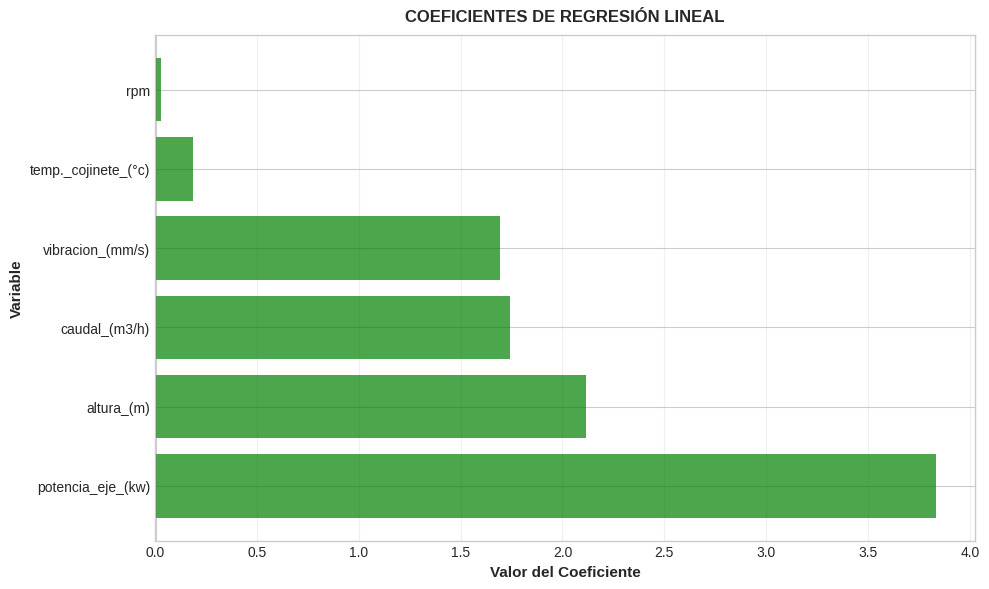

In [16]:
# Coeficientes del Modelo
coeficientes_df = pd.DataFrame({
    'Variable': features,
    'Coeficiente': modelo.coef_,
    'Importancia_Relativa': np.abs(modelo.coef_)
}).sort_values('Importancia_Relativa', ascending=False)

print("COEFICIENTES DEL MODELO")
print("=" * 70)
print(f"\n{'Variable':<25} {'Coeficiente':>15} {'Importancia':>15}")
print("-" * 70)

for _, row in coeficientes_df.iterrows():
    print(f"{row['Variable']:<25} {row['Coeficiente']:>15.4f} {row['Importancia_Relativa']:>15.4f}")

print("=" * 70)

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in coeficientes_df['Coeficiente']]
plt.barh(coeficientes_df['Variable'], coeficientes_df['Coeficiente'], color=colors, alpha=0.7)
plt.xlabel('Valor del Coeficiente', fontsize=11, fontweight='bold')
plt.ylabel('Variable', fontsize=11, fontweight='bold')
plt.title('COEFICIENTES DE REGRESIÓN LINEAL', fontsize=12, fontweight='bold', pad=10)
plt.axvline(x=0, color='black', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('coeficientes_modelo.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Ecuación del Modelo
ecuacion = f"Eficiencia = {modelo.intercept_:.2f}"

for i, feature in enumerate(features):
    coef = modelo.coef_[i]
    if coef >= 0:
        ecuacion += f" + {coef:.4f} * {feature}"
    else:
        ecuacion += f" - {abs(coef):.4f} * {feature}"

print("ECUACIÓN DEL MODELO")
print("=" * 80)
print(f"\n{ecuacion}\n")
print("=" * 80)

ECUACIÓN DEL MODELO

Eficiencia = -171.93 + 1.7429 * caudal_(m3/h) + 2.1168 * altura_(m) + 3.8331 * potencia_eje_(kw) + 1.6954 * vibracion_(mm/s) + 0.1878 * temp._cojinete_(°c) + 0.0316 * rpm



In [18]:
# 7. Predicciones
y_pred = modelo.predict(X_test)

comparacion_df = pd.DataFrame({
    'Valor_Real': y_test,
    'Valor_Predicho': y_pred,
    'Diferencia': y_test - y_pred,
    'Error_Relativo_%': np.where(
        y_test != 0,
        ((y_test - y_pred) / y_test) * 100,
        np.nan
    )
})

print("PREDICCIONES DEL MODELO")
print("=" * 80)
print("\nPrimeras 10 predicciones:")
display(comparacion_df.head(10).round(3))

PREDICCIONES DEL MODELO

Primeras 10 predicciones:


,Valor_Real,Valor_Predicho,Diferencia,Error_Relativo_%
0,83.524,80.997,2.527,3.025
1,76.055,73.549,2.506,3.295
2,17.478,25.348,-7.870,-45.031
3,52.679,51.158,1.522,2.888
4,72.595,61.239,11.356,15.642
5,64.941,64.478,0.463,0.713
6,12.346,2.176,10.170,82.375
7,49.799,51.181,-1.382,-2.775
8,16.851,23.612,-6.760,-40.118
9,78.108,81.236,-3.128,-4.004


In [19]:
# Métricas de Evaluación
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / np.where(y_test != 0, y_test, 1))) * 100

print("=" * 70)
print("MÉTRICAS DE EVALUACIÓN DEL MODELO".center(70))
print("=" * 70)
print(f"\n{'Métrica':<35} {'Valor':>15} {'Interpretación':>20}")
print("-" * 70)
print(f"{'MAE (Error Absoluto Medio)':<35} {mae:>15.4f} {'%':>20}")
print(f"{'RMSE (Error Cuadrático Medio)':<35} {rmse:>15.4f} {'%':>20}")
print(f"{'R² (Coeficiente de Determinación)':<35} {r2:>15.4f} {'(0-1)':>20}")
print(f"{'MAPE (Error Porcentual)':<35} {mape:>15.2f} {'%':>20}")
print("\n" + "=" * 70)

if r2 >= 0.9:
    interpretacion = "Excelente ajuste"
elif r2 >= 0.7:
    interpretacion = "Buen ajuste"
elif r2 >= 0.5:
    interpretacion = "Ajuste moderado"
else:
    interpretacion = "Ajuste deficiente"

print(f"\nInterpretación: {interpretacion}")
print(f" El modelo explica el {r2*100:.2f}% de la variabilidad de los datos")
print("=" * 70)

                  MÉTRICAS DE EVALUACIÓN DEL MODELO                   

Métrica                                       Valor       Interpretación
----------------------------------------------------------------------
MAE (Error Absoluto Medio)                   4.3610                    %
RMSE (Error Cuadrático Medio)                5.9005                    %
R² (Coeficiente de Determinación)            0.9449                (0-1)
MAPE (Error Porcentual)                       12.31                    %


Interpretación: Excelente ajuste
 El modelo explica el 94.49% de la variabilidad de los datos


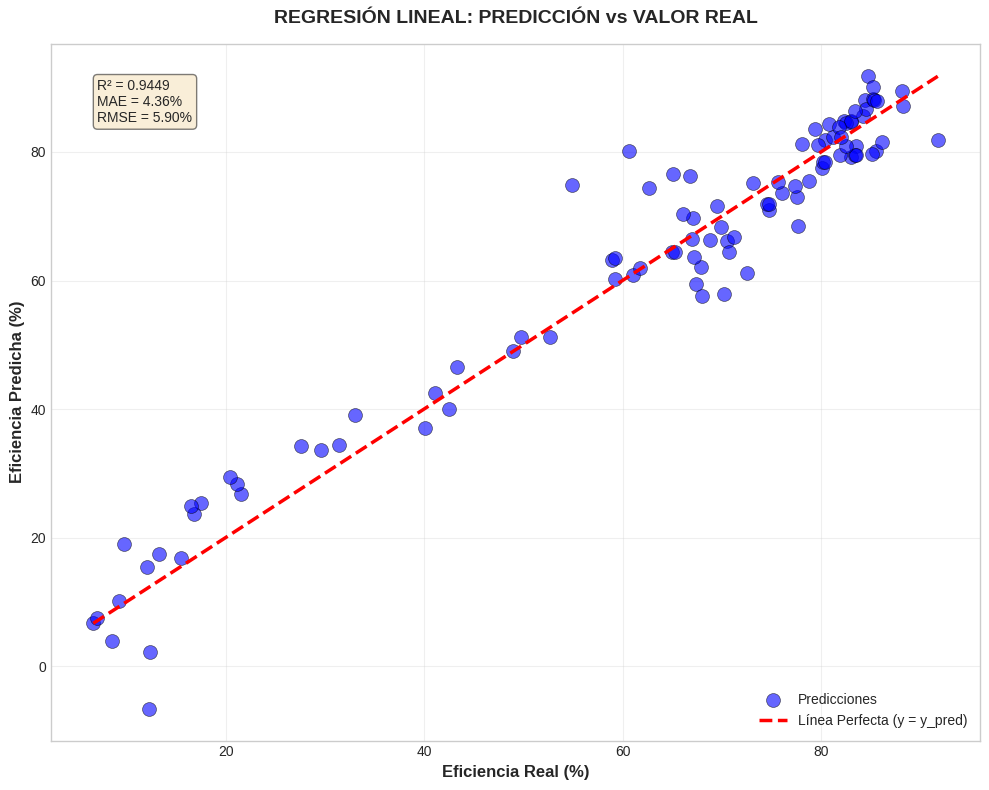

In [20]:
# Predicción vs Real
plt.figure(figsize=(10, 8))
plt.scatter(
    y_test, y_pred,
    alpha=0.6,
    s=100,
    color='blue',
    edgecolors='black',
    linewidth=0.5,
    label='Predicciones'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2.5,
    label='Línea Perfecta (y = y_pred)'
)

plt.xlabel('Eficiencia Real (%)', fontsize=12, fontweight='bold')
plt.ylabel('Eficiencia Predicha (%)', fontsize=12, fontweight='bold')
plt.title('REGRESIÓN LINEAL: PREDICCIÓN vs VALOR REAL',
          fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)

texto_metricas = f'R² = {r2:.4f}\nMAE = {mae:.2f}%\nRMSE = {rmse:.2f}%'
plt.annotate(
    texto_metricas,
    xy=(0.05, 0.95),
    xycoords='axes fraction',
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

plt.tight_layout()
plt.savefig('prediccion_vs_real.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_28860/263778643.py:148: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_28860/263778643.py:148: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_28860/263778643.py:149: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  plt.savefig('curva_HQ_BEP.png', dpi=300, bbox_inches='tight', facecolor='white')
/tmp/ipykernel_28860/263778643.py:149: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  plt.savefig('curva_HQ_BEP.png', dpi=300, bbox_inches='tight', facecolor='white')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9733 (\N{BLACK STAR}) mi

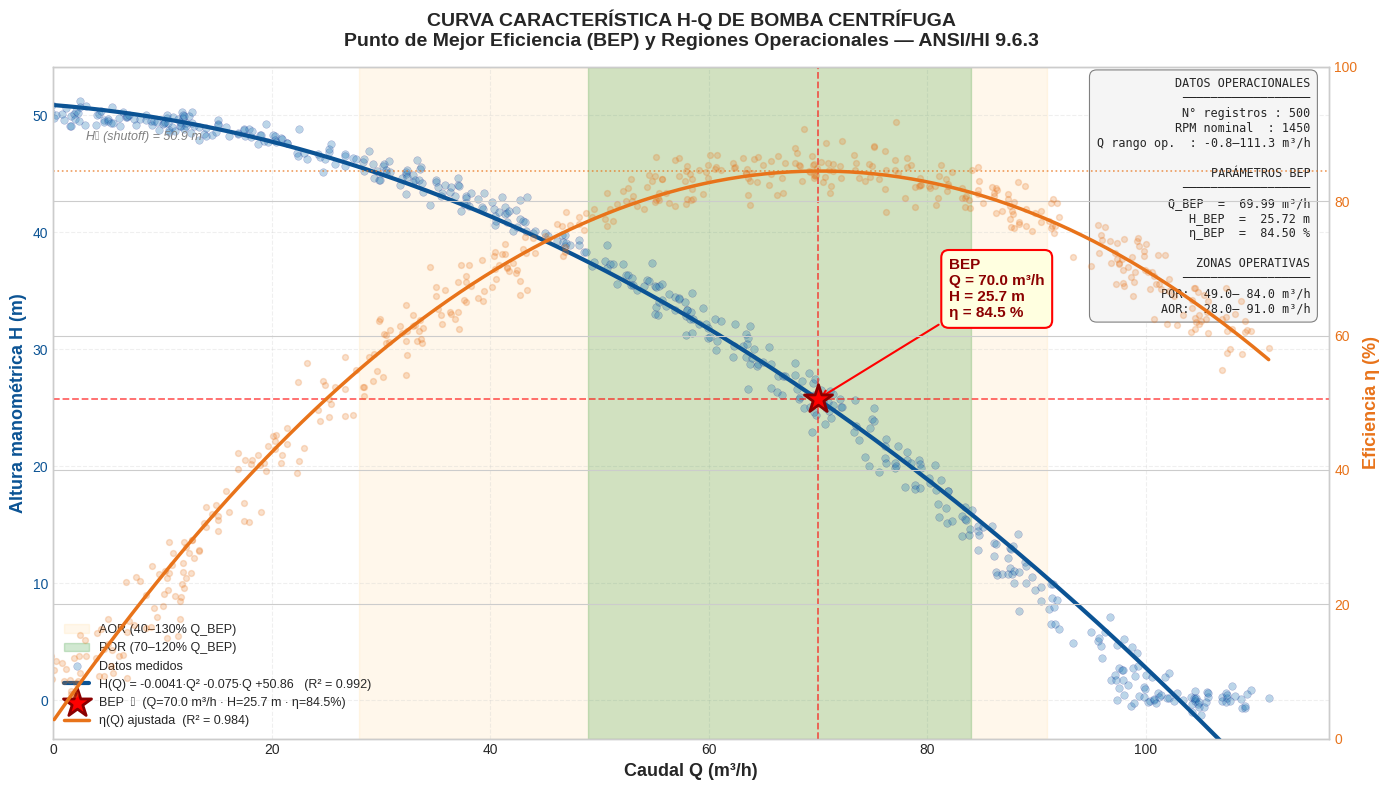


════════════════════════════════════════════════════════════════════════
                REPORTE TÉCNICO — CURVA CARACTERÍSTICA H-Q              
════════════════════════════════════════════════════════════════════════

■ ECUACIÓN CURVA H-Q AJUSTADA   (R² = 0.9916):
   H(Q) = -0.00406·Q²  -0.0753·Q  +50.855

■ ECUACIÓN CURVA η-Q AJUSTADA   (R² = 0.9836):
   η(Q) = -0.01663·Q²  +2.3346·Q  +2.589

■ PUNTO DE MEJOR EFICIENCIA (BEP):
   • Caudal óptimo      Q_BEP =    69.99  m³/h
   • Altura óptima      H_BEP =    25.72  m
   • Eficiencia máxima  η_BEP =    84.50  %
   • Altura shutoff     H₀    =    50.86  m   (a Q = 0)

■ REGIONES OPERACIONALES (ANSI/HI 9.6.3):
   • POR  (70–120% Q_BEP) :  48.99 –  83.99 m³/h   ← zona recomendada
   • AOR  (40–130% Q_BEP) :  28.00 –  90.99 m³/h   ← límites aceptables
════════════════════════════════════════════════════════════════════════


In [21]:
# ═══════════════════════════════════════════════════════════════════════════
#   CURVA CARACTERÍSTICA H-Q CON PUNTO DE MEJOR EFICIENCIA (BEP)
#   Análisis hidráulico de bomba centrífuga — ANSI/HI 9.6.3

import numpy as np
import matplotlib.pyplot as plt

# ─── 1) Ordenar datos y ajustar curvas características ─────────────────────
df_sorted = df.sort_values('caudal_(m3/h)').reset_index(drop=True)
Q   = df_sorted['caudal_(m3/h)'].values
H   = df_sorted['altura_(m)'].values
eta = df_sorted['eficiencia_(%)'].values

# Ajuste polinómico curva H-Q (2° grado — forma teórica de bomba centrífuga)
#   H(Q) = C·Q² + B·Q + H₀
coef_hq   = np.polyfit(Q, H, 2)
poly_hq   = np.poly1d(coef_hq)
H0_shutoff = poly_hq(0)                       # Altura a caudal cero (shutoff)

# Ajuste polinómico curva de eficiencia η-Q (2° grado)
coef_eta = np.polyfit(Q, eta, 2)
poly_eta = np.poly1d(coef_eta)

# Curvas suavizadas para el trazado
Q_fit   = np.linspace(max(0.1, Q.min()), Q.max(), 300)
H_fit   = poly_hq(Q_fit)
eta_fit = poly_eta(Q_fit)

# R² de los ajustes
r2_hq  = np.corrcoef(H,   poly_hq(Q))[0, 1]**2
r2_eta = np.corrcoef(eta, poly_eta(Q))[0, 1]**2

# ─── 2) Localizar BEP desde la curva ajustada ──────────────────────────────
idx_bep = np.argmax(eta_fit)
Q_bep   = Q_fit[idx_bep]
H_bep   = poly_hq(Q_bep)
eta_bep = eta_fit[idx_bep]

# Zonas operacionales ANSI/HI 9.6.3
Q_por_min, Q_por_max = 0.70 * Q_bep, 1.20 * Q_bep   # Preferred Operating Region
Q_aor_min, Q_aor_max = 0.40 * Q_bep, 1.30 * Q_bep   # Allowable Operating Region

# ─── 3) Construcción del gráfico ───────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')

# Sombrear regiones operacionales
ax1.axvspan(Q_aor_min, Q_aor_max, alpha=0.08, color='orange',
            label='AOR (40–130% Q_BEP)', zorder=0)
ax1.axvspan(Q_por_min, Q_por_max, alpha=0.18, color='green',
            label='POR (70–120% Q_BEP)', zorder=1)

# Puntos de datos reales (dispersión)
ax1.scatter(Q, H, s=30, alpha=0.30, color='#1f77b4',
            edgecolor='navy', linewidth=0.3,
            label='Datos medidos', zorder=2)

# Curva H-Q ajustada
ecuacion_hq = (f'H(Q) = {coef_hq[0]:+.4f}·Q² '
               f'{coef_hq[1]:+.3f}·Q '
               f'{coef_hq[2]:+.2f}   (R² = {r2_hq:.3f})')
ax1.plot(Q_fit, H_fit, color='#0b5394', linewidth=3,
         label=ecuacion_hq, zorder=3)

# Marcar BEP con estrella
ax1.scatter(Q_bep, H_bep, s=450, color='red', marker='*',
            edgecolor='darkred', linewidth=2, zorder=10,
            label=f'BEP  ★  (Q={Q_bep:.1f} m³/h · H={H_bep:.1f} m · η={eta_bep:.1f}%)')

# Líneas de referencia hacia el BEP
ax1.axvline(Q_bep, color='red', linestyle='--', linewidth=1.3, alpha=0.6, zorder=4)
ax1.axhline(H_bep, color='red', linestyle='--', linewidth=1.3, alpha=0.6, zorder=4)

# Anotación del BEP
ax1.annotate(f'BEP\nQ = {Q_bep:.1f} m³/h\nH = {H_bep:.1f} m\nη = {eta_bep:.1f} %',
             xy=(Q_bep, H_bep),
             xytext=(Q_bep + 12, H_bep + 7),
             fontsize=11, fontweight='bold', color='darkred',
             bbox=dict(boxstyle='round,pad=0.5',
                       facecolor='lightyellow',
                       edgecolor='red', linewidth=1.5),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# Indicar altura de shutoff
ax1.annotate(f'H₀ (shutoff) = {H0_shutoff:.1f} m',
             xy=(0, H0_shutoff),
             xytext=(3, H0_shutoff - 3),
             fontsize=9, color='gray', style='italic')

# Configuración eje primario (altura)
ax1.set_xlabel('Caudal Q (m³/h)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Altura manométrica H (m)', fontsize=13,
               fontweight='bold', color='#0b5394')
ax1.tick_params(axis='y', labelcolor='#0b5394')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(0, Q.max() * 1.05)
ax1.set_ylim(bottom=min(0, H.min() - 2))

# ─── 4) Eje secundario: curva de eficiencia ────────────────────────────────
ax2 = ax1.twinx()
ax2.plot(Q_fit, eta_fit, color='#e8731a', linewidth=2.5,
         label=f'η(Q) ajustada  (R² = {r2_eta:.3f})', zorder=3)
ax2.scatter(Q, eta, s=18, alpha=0.22, color='#e8731a', zorder=2)
ax2.axhline(eta_bep, color='#e8731a', linestyle=':', linewidth=1.2, alpha=0.7)
ax2.set_ylabel('Eficiencia η (%)', fontsize=13,
               fontweight='bold', color='#e8731a')
ax2.tick_params(axis='y', labelcolor='#e8731a')
ax2.set_ylim(0, 100)

# ─── 5) Título y leyenda unificada ─────────────────────────────────────────
plt.title('CURVA CARACTERÍSTICA H-Q DE BOMBA CENTRÍFUGA\n'
          'Punto de Mejor Eficiencia (BEP) y Regiones Operacionales — ANSI/HI 9.6.3',
          fontsize=14, fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='lower left', fontsize=9, framealpha=0.95,
           edgecolor='gray', fancybox=True)

# Caja técnica con resumen
info_text = (f"DATOS OPERACIONALES\n"
             f"──────────────────\n"
             f"N° registros : {len(df)}\n"
             f"RPM nominal  : {df['rpm'].median():.0f}\n"
             f"Q rango op.  : {Q.min():.1f}–{Q.max():.1f} m³/h\n"
             f"\nPARÁMETROS BEP\n"
             f"──────────────────\n"
             f"Q_BEP  = {Q_bep:6.2f} m³/h\n"
             f"H_BEP  = {H_bep:6.2f} m\n"
             f"η_BEP  = {eta_bep:6.2f} %\n"
             f"\nZONAS OPERATIVAS\n"
             f"──────────────────\n"
             f"POR: {Q_por_min:5.1f}–{Q_por_max:5.1f} m³/h\n"
             f"AOR: {Q_aor_min:5.1f}–{Q_aor_max:5.1f} m³/h")

ax1.text(0.985, 0.985, info_text, transform=ax1.transAxes,
         fontsize=8.5, verticalalignment='top', horizontalalignment='right',
         family='monospace',
         bbox=dict(boxstyle='round,pad=0.6',
                   facecolor='#f5f5f5',
                   edgecolor='gray', linewidth=0.8))

plt.tight_layout()
plt.savefig('curva_HQ_BEP.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ─── 6) Reporte técnico en consola ─────────────────────────────────────────
print("\n" + "═" * 72)
print("  REPORTE TÉCNICO — CURVA CARACTERÍSTICA H-Q".center(72))
print("═" * 72)
print(f"\n ECUACIÓN CURVA H-Q AJUSTADA   (R² = {r2_hq:.4f}):")
print(f"   H(Q) = {coef_hq[0]:+.5f}·Q²  {coef_hq[1]:+.4f}·Q  {coef_hq[2]:+.3f}")
print(f"\n ECUACIÓN CURVA η-Q AJUSTADA   (R² = {r2_eta:.4f}):")
print(f"   η(Q) = {coef_eta[0]:+.5f}·Q²  {coef_eta[1]:+.4f}·Q  {coef_eta[2]:+.3f}")
print(f"\n PUNTO DE MEJOR EFICIENCIA (BEP):")
print(f"   • Caudal óptimo      Q_BEP = {Q_bep:8.2f}  m³/h")
print(f"   • Altura óptima      H_BEP = {H_bep:8.2f}  m")
print(f"   • Eficiencia máxima  η_BEP = {eta_bep:8.2f}  %")
print(f"   • Altura shutoff     H₀    = {H0_shutoff:8.2f}  m   (a Q = 0)")
print(f"\n REGIONES OPERACIONALES (ANSI/HI 9.6.3):")
print(f"   • POR  (70–120% Q_BEP) : {Q_por_min:6.2f} – {Q_por_max:6.2f} m³/h   ← zona recomendada")
print(f"   • AOR  (40–130% Q_BEP) : {Q_aor_min:6.2f} – {Q_aor_max:6.2f} m³/h   ← límites aceptables")
print("═" * 72)